# One4All — Error Analysis

This notebook performs a structured error analysis on the One4All hallucination-detection model.

**Goal**: understand *where* the model fails — identifying patterns in false positives (FP) and false negatives (FN) across text length, answer structure, confidence scores, question type, models, and layers.

**Dataset**: HaluEval — binary hallucination detection (0 = no hallucination, 1 = hallucination)  
**Models**: Qwen2.5-7B (trainer), Falcon3-7B-Base (tester)  
**Layers**: `attn`, `hidden`, `mlp`

In [7]:
%pip install --quiet numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\fonta\Desktop\Papero\HallucinationDetection\.venv\Scripts\python.exe: No module named pip


In [ ]:
import json
import os
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
 )
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
BASE_DIR  = PROJECT_ROOT / "results" / "one4all_experiment_details"
LAYERS    = ["attn", "hidden", "mlp"]
MODELS    = []
PLOTS_DIR = PROJECT_ROOT / "src" / "plots" / "error_analysis"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data Loading

In [9]:
def load_predictions(base_dir: Path) -> pd.DataFrame:
    """Load all prediction JSON files into a single flat DataFrame."""
    if not base_dir.exists():
        raise FileNotFoundError(f"Base dir not found: {base_dir}")
    rows = []
    for fname in base_dir.rglob("*_test_predictions.json"):
        with open(fname, encoding="utf-8") as f:
            payload = json.load(f)
        model_name = payload.get("model_name", "unknown")
        layer_type = payload.get("layer_type")
        if not layer_type:
            layer_dir = fname.parent.name
            layer_type = layer_dir.replace("layer_", "")
        rel_parts = fname.relative_to(base_dir).parts
        experiment = rel_parts[0] if rel_parts else "unknown"
        seed = rel_parts[1] if len(rel_parts) > 1 else ""
        for rec in payload["records"]:
            instance   = rec["Istanza Dataset"]
            question   = instance["question"]
            # Split question text from [Further Knowledge] context
            if "[Further Knowledge]" in question:
                q_text, ctx = question.split("[Further Knowledge]", 1)
            else:
                q_text, ctx = question, ""
            rows.append({
                "experiment":    experiment,
                "seed":          seed,
                "model":          model_name,
                "layer":          layer_type,
                "instance_id":    instance["instance_id"],
                "question":       q_text.strip(),
                "context":        ctx.strip(),
                "llm_answer":     rec["Risposta data dall LLM"].strip(),
                "true_answer":    rec["Risposta vera"].strip(),
                "pred":           int(rec["Predizione One4All"]),
                "label":          int(rec["GroundTruth per One4All"]),
                "label_balanced": int(rec["GroundTruth split bilanciato"]),
                "prob":           float(rec["Probabilita One4All"]),
            })
    return pd.DataFrame(rows)

df = load_predictions(BASE_DIR)
print(f"Total records loaded: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
MODELS = sorted(df["model"].unique())
print(f"Models: {MODELS}")
df.head(3)

Total records loaded: 78,492
Columns: ['experiment', 'seed', 'model', 'layer', 'instance_id', 'question', 'context', 'llm_answer', 'true_answer', 'pred', 'label', 'label_balanced', 'prob']
Models: ['Llama-3.1-8B-Instruct', 'gemma-2-9b-it']


,experiment,seed,model,layer,instance_id,question,context,llm_answer,true_answer,pred,label,label_balanced,prob
0,GemmaToLlama_BBC,seed_42,gemma-2-9b-it,attn,17938,"If an adder is a wine, then an adder is drunk ...",,no,yes,1,1,1,0.999993
1,GemmaToLlama_BBC,seed_42,gemma-2-9b-it,attn,16039,"If an adder is a horse, then an adder cannot o...",,no,no,0,0,0,0.000078
2,GemmaToLlama_BBC,seed_42,gemma-2-9b-it,attn,5948,"If an ant is a country, then an ant has an its...",,Yes,yes,0,0,0,0.000063


## 3. Feature Engineering

In [10]:
def word_count(text: str) -> int:
    return len(text.split())

def sentence_count(text: str) -> int:
    return max(1, len(re.split(r'[.!?]+', text)))

def has_numbers(text: str) -> bool:
    return bool(re.search(r'\d', text))

def capitalized_word_ratio(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    cap = sum(1 for w in words if w and w[0].isupper())
    return cap / len(words)

def avg_word_length(text: str) -> float:
    words = [w for w in re.findall(r'\b\w+\b', text)]
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

def question_type(q: str) -> str:
    q_lower = q.lower().strip()
    for kw in ["who", "what", "when", "where", "which", "how", "why", "is ", "are ", "was ", "were ", "did ", "does ", "do ", "can ", "has ", "have "]:
        if q_lower.startswith(kw):
            return kw.strip()
    return "other"

def answer_overlap_ratio(llm: str, truth: str) -> float:
    """Fraction of words in truth that also appear in llm_answer (recall-style overlap)."""
    truth_words = set(re.findall(r'\b\w+\b', truth.lower()))
    llm_words   = set(re.findall(r'\b\w+\b', llm.lower()))
    if not truth_words:
        return 1.0
    return len(truth_words & llm_words) / len(truth_words)

# --- Compute features ---
for col, fn in [
    ("q_word_count",   lambda r: word_count(r["question"])),
    ("ctx_word_count", lambda r: word_count(r["context"])),
    ("llm_word_count", lambda r: word_count(r["llm_answer"])),
    ("tru_word_count", lambda r: word_count(r["true_answer"])),
    ("llm_sent_count", lambda r: sentence_count(r["llm_answer"])),
    ("llm_has_numbers",lambda r: has_numbers(r["llm_answer"])),
    ("llm_cap_ratio",  lambda r: capitalized_word_ratio(r["llm_answer"])),
    ("llm_avg_wlen",   lambda r: avg_word_length(r["llm_answer"])),
    ("q_type",         lambda r: question_type(r["question"])),
    ("overlap_ratio",  lambda r: answer_overlap_ratio(r["llm_answer"], r["true_answer"])),
]:
    df[col] = df.apply(fn, axis=1)

# Error type
def error_type(row):
    p, l = row["pred"], row["label"]
    if   p == 1 and l == 1: return "TP"
    elif p == 0 and l == 0: return "TN"
    elif p == 1 and l == 0: return "FP"
    else:                   return "FN"

df["error_type"] = df.apply(error_type, axis=1)
df["correct"]    = (df["pred"] == df["label"]).astype(int)

print(df[["error_type", "correct"]].value_counts().sort_index())
df[["q_word_count", "ctx_word_count", "llm_word_count", "overlap_ratio", "prob"]].describe()

error_type  correct
FN          0           3072
FP          0           3551
TN          1          35632
TP          1          36237
Name: count, dtype: int64


,q_word_count,ctx_word_count,llm_word_count,overlap_ratio,prob
count,78492.000000,78492.000000,78492.000000,78492.000000,78492.000000
mean,12.996140,11.302974,11.592494,0.533136,0.503659
std,5.683733,24.492917,15.584387,0.487255,0.470836
min,4.000000,0.000000,0.000000,0.000000,0.000011
25%,12.000000,0.000000,1.000000,0.000000,0.000131
50%,13.000000,0.000000,1.000000,1.000000,0.546215
75%,14.000000,0.000000,34.000000,1.000000,0.999346
max,100.000000,197.000000,48.000000,1.000000,0.999995


## 6. Error Type Distribution

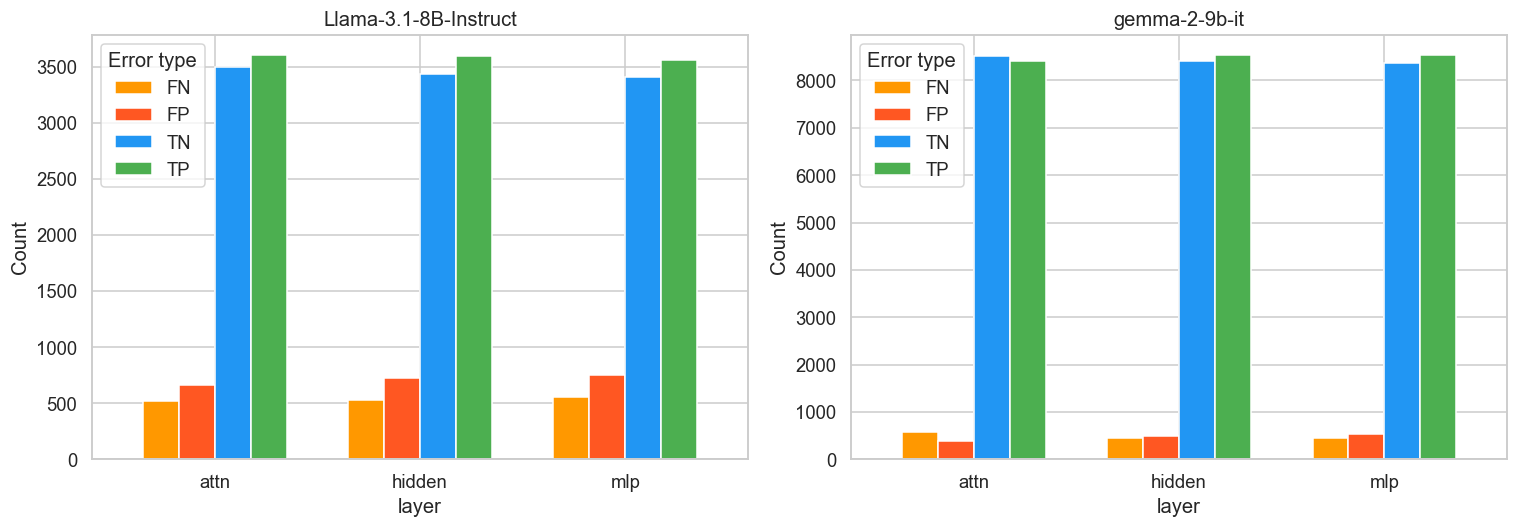

In [11]:
layer_labels = {"attn": "Attention", "hidden": "Hidden", "mlp": "MLP"}

et_counts = (
    df.groupby(["model", "layer", "error_type"])
    .size()
    .reset_index(name="count")
)

palette = {"TP": "#4CAF50", "TN": "#2196F3", "FP": "#FF5722", "FN": "#FF9800"}

fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 5), sharey=False)

for ax, model in zip(axes, MODELS):
    sub = et_counts[et_counts["model"] == model].pivot(
        index="layer", columns="error_type", values="count"
    ).fillna(0)
    sub.plot(kind="bar", ax=ax, color=[palette.get(c, "grey") for c in sub.columns],
             stacked=False, rot=0, width=0.7)
    ax.set_title(f"{model}")
    ax.set_ylabel("Count")
    ax.legend(title="Error type")

plt.tight_layout()
fig.savefig(PLOTS_DIR / "error_type_breakdown.pdf", bbox_inches="tight")
plt.show()


## 7. Confidence Score Analysis

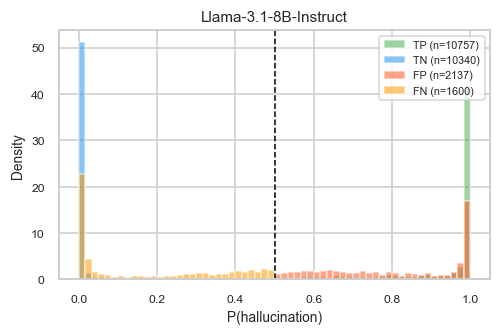

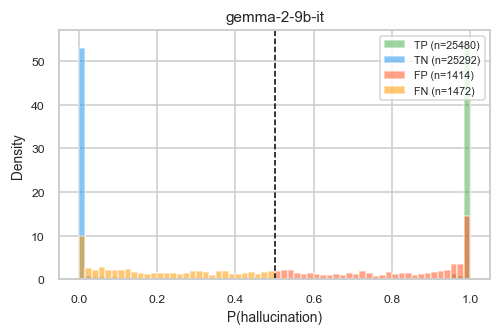

In [12]:
for model in MODELS:
    fig, ax = plt.subplots(figsize=(4.5, 3))
    sub = df[df["model"] == model]
    for et, color in palette.items():
        vals = sub.loc[sub["error_type"] == et, "prob"]
        ax.hist(vals, bins=30, alpha=0.55, label=f"{et} (n={len(vals)})", color=color, density=True)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{model}", fontsize=10)
    ax.set_xlabel("P(hallucination)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)
    plt.tight_layout(pad=0.4)
    model_slug = model.replace(".", "_").replace("-", "_")
    fig.savefig(PLOTS_DIR / f"confidence_score_distribution_{model_slug}.pdf", bbox_inches="tight")
    plt.show()


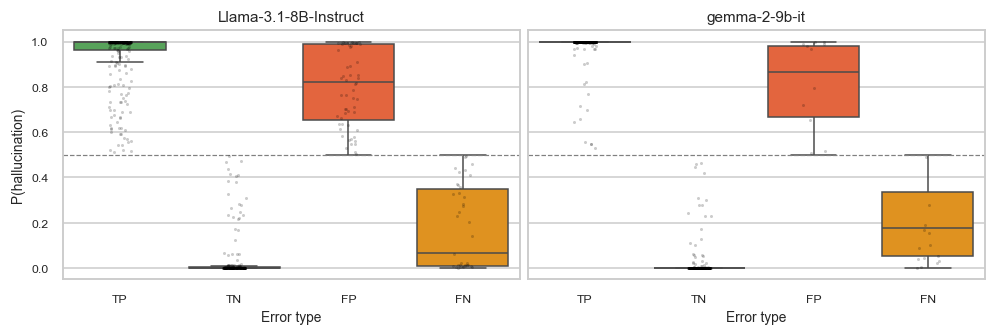

In [13]:
order = ["TP", "TN", "FP", "FN"]
fig, axes = plt.subplots(1, len(MODELS), figsize=(9, 3), sharey=True)

for ax, model in zip(axes, MODELS):
    sub = df[df["model"] == model]
    sns.boxplot(data=sub, x="error_type", y="prob", order=order,
                palette=palette, ax=ax, showfliers=False)
    sns.stripplot(data=sub.sample(min(600, len(sub)), random_state=42),
                  x="error_type", y="prob", order=order,
                  color="black", alpha=0.2, size=2, ax=ax, jitter=True)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(f"{model}", fontsize=10)
    ax.set_xlabel("Error type", fontsize=9)
    ax.set_ylabel("P(hallucination)" if ax is axes[0] else "", fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "confidence_score_boxstrip.pdf", bbox_inches="tight")
plt.show()


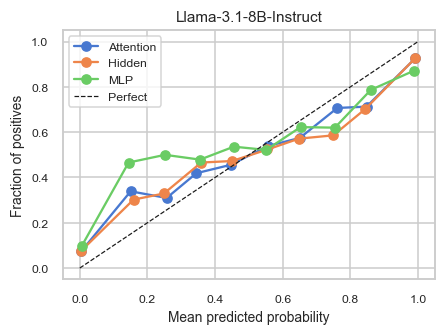

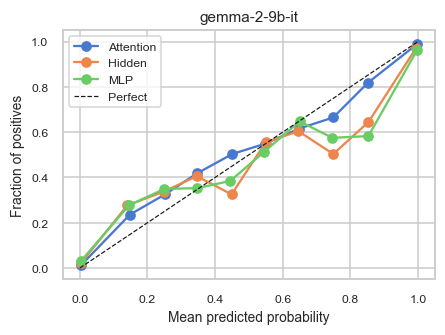

In [14]:
# Calibration curves
for model in MODELS:
    fig, ax = plt.subplots(figsize=(4, 3))
    for layer in ["attn", "hidden", "mlp"]:
        sub = df[(df["model"] == model) & (df["layer"] == layer)]
        frac_pos, mean_pred = calibration_curve(sub["label"], sub["prob"], n_bins=10)
        ax.plot(mean_pred, frac_pos, marker="o", label=layer_labels[layer])
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
    ax.set_title(f"{model}", fontsize=10)
    ax.set_xlabel("Mean predicted probability", fontsize=9)
    ax.set_ylabel("Fraction of positives", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)
    plt.tight_layout(pad=0.4)
    model_slug = model.replace(".", "_").replace("-", "_")
    fig.savefig(PLOTS_DIR / f"calibration_curves_{model_slug}.pdf", bbox_inches="tight")
    plt.show()


## 19. Semantic Analysis — 2D Embedding Space

Questions (and question + context) are encoded with a sentence-transformer model and projected to 2D via UMAP or t-SNE. Each point is one unique question instance, coloured by the error type produced by One4All for a chosen layer.

> **Config cell below**: change `EMBED_MODEL`, `REDUCE_METHOD`, and `LAYER_FOR_PLOT` to explore different settings.

In [15]:
%pip install --quiet sentence-transformers umap-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\fonta\Desktop\Papero\HallucinationDetection\.venv\Scripts\python.exe: No module named pip


In [17]:
from sentence_transformers import SentenceTransformer

# ── Configuration ─────────────────────────────────────────────────
EMBED_MODEL    = "all-MiniLM-L6-v2"  # small (~90 MB), fast, solid quality
REDUCE_METHOD  = "umap"              # "umap" | "tsne"
LAYER_FOR_PLOT = "attn"              # which layer's predictions to colour by
# ──────────────────────────────────────────────────────────────────

# Build a combined question+context column (truncated naturally by the encoder)
df["question_ctx"] = df["question"] + " [SEP] " + df["context"]

# Deduplicate: the same instance_id has identical question text across layers
unique_q = (
    df.drop_duplicates("instance_id")
      [["instance_id", "question", "question_ctx"]]
      .reset_index(drop=True)
)

encoder = SentenceTransformer(EMBED_MODEL)

print(f"Encoding {len(unique_q)} unique instances with '{EMBED_MODEL}'...")
emb_q  = encoder.encode(unique_q["question"].tolist(),     batch_size=64, show_progress_bar=True)
emb_qc = encoder.encode(unique_q["question_ctx"].tolist(), batch_size=64, show_progress_bar=True)
print(f"Done — embedding shape: {emb_q.shape}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Encoding 16499 unique instances with 'all-MiniLM-L6-v2'...


Batches:  11%|█         | 29/258 [00:08<01:08,  3.32it/s]


KeyboardInterrupt: 

In [ ]:
def reduce_2d(embeddings, method=REDUCE_METHOD, seed=42):
    if method == "umap":
        import umap as umap_lib
        reducer = umap_lib.UMAP(n_components=2, random_state=seed, n_neighbors=15, min_dist=0.1)
    else:
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=seed, perplexity=40, n_iter=1000, verbose=0)
    return reducer.fit_transform(embeddings)

print(f"Reducing embeddings with {REDUCE_METHOD.upper()} — this may take a minute...")
coords_q  = reduce_2d(emb_q)
coords_qc = reduce_2d(emb_qc)

for prefix, coords in [("q", coords_q), ("qc", coords_qc)]:
    unique_q[f"x_{prefix}"] = coords[:, 0]
    unique_q[f"y_{prefix}"] = coords[:, 1]

print("Done.")

Reducing embeddings with UMAP — this may take a minute...
Done.


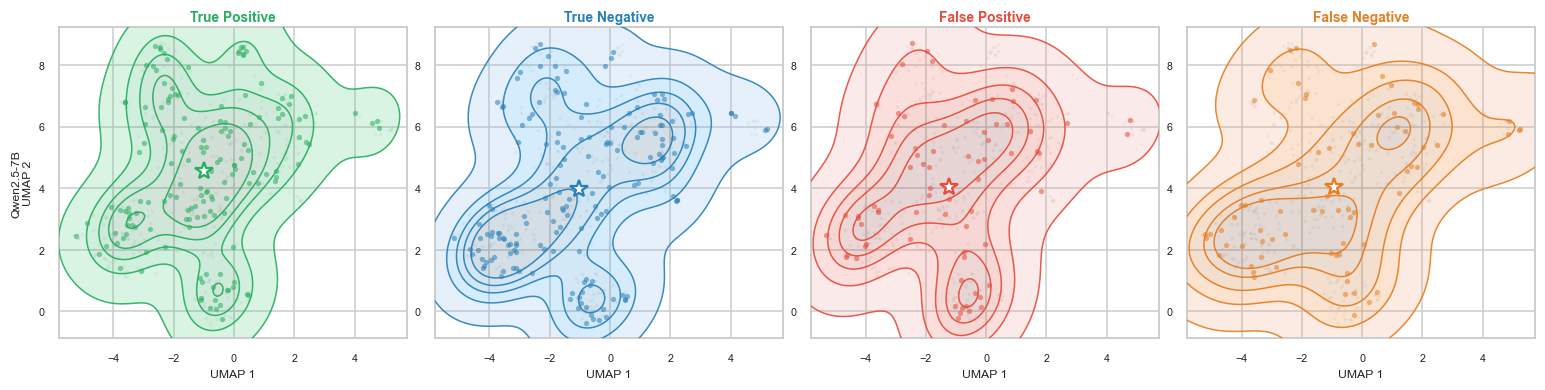

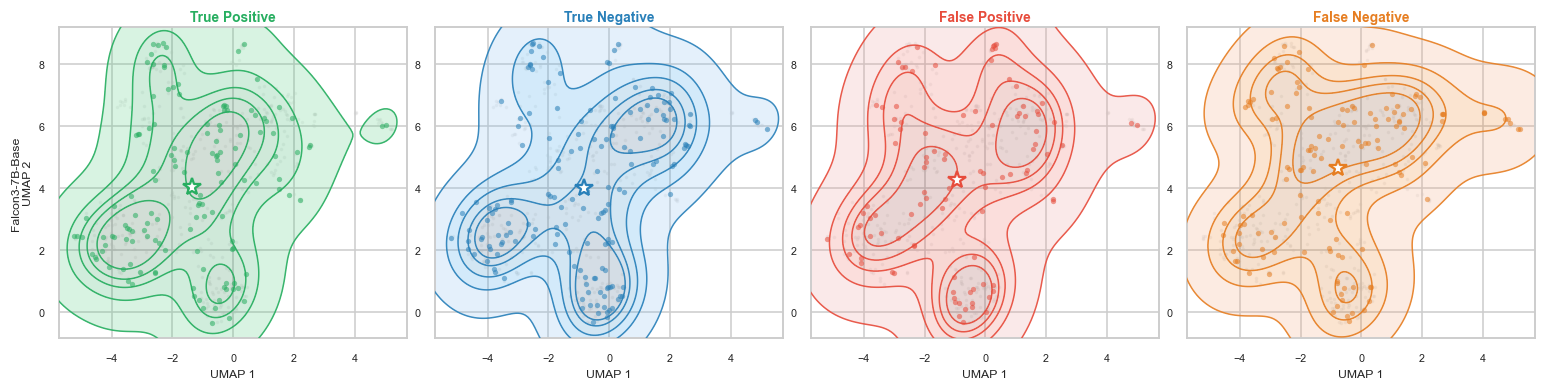

In [ ]:
# Join 2D coordinates back — pick the layer whose predictions colour the points
plot_df = (
    df[df["layer"] == LAYER_FOR_PLOT][["model", "instance_id", "error_type", "prob"]]
      .merge(unique_q[["instance_id", "x_q", "y_q", "x_qc", "y_qc"]], on="instance_id", how="left")
      .dropna(subset=["x_q"])
)

# Cap at 1000 points total (stratified by model × error_type to preserve distribution)
MAX_PLOT_POINTS = 1000
if len(plot_df) > MAX_PLOT_POINTS:
    _total = len(plot_df)
    plot_df = pd.concat([
        g.sample(n=max(1, round(MAX_PLOT_POINTS * len(g) / _total)), random_state=42)
        for _, g in plot_df.groupby(["model", "error_type"])
    ]).reset_index(drop=True)

ET_ORDER  = ["TP", "TN", "FP", "FN"]
ET_COLORS = {"TP": "#27ae60", "TN": "#2980b9", "FP": "#e74c3c", "FN": "#e67e22"}
ET_LABELS = {
    "TP": "True Positive",
    "TN": "True Negative",
    "FP": "False Positive",
    "FN": "False Negative",
}

# ── Plot A: small multiples — one figure per model, one panel per error type ──
for model in MODELS:
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    sub = plot_df[plot_df["model"] == model]

    for col_i, et in enumerate(ET_ORDER):
        ax   = axes[col_i]
        mask = sub["error_type"] == et
        bg   = sub[~mask]
        fg   = sub[mask]

        ax.scatter(bg["x_q"], bg["y_q"],
                   color="#cecece", alpha=0.25, s=5, linewidths=0, zorder=1)

        if fg.shape[0] > 30:
            try:
                sns.kdeplot(x=fg["x_q"], y=fg["y_q"], ax=ax,
                            fill=True,  color=ET_COLORS[et], alpha=0.22,
                            levels=6, thresh=0.05, zorder=2)
                sns.kdeplot(x=fg["x_q"], y=fg["y_q"], ax=ax,
                            fill=False, color=ET_COLORS[et], alpha=0.9,
                            levels=6, thresh=0.05, linewidths=1.0, zorder=3)
            except Exception:
                pass

        ax.scatter(fg["x_q"], fg["y_q"],
                   color=ET_COLORS[et], alpha=0.55, s=12, linewidths=0, zorder=4)

        if not fg.empty:
            cx, cy = fg["x_q"].mean(), fg["y_q"].mean()
            ax.plot(cx, cy, marker="*", markersize=12, zorder=5,
                    color="white", markeredgecolor=ET_COLORS[et], markeredgewidth=1.5)

        ax.set_title(f"{ET_LABELS[et]}",
                     fontsize=9, color=ET_COLORS[et], fontweight="bold", pad=4)
        ax.set_xlabel(f"{REDUCE_METHOD.upper()} 1", fontsize=8)
        ax.set_ylabel(
            f"{model}\n{REDUCE_METHOD.upper()} 2" if col_i == 0 else "",
            fontsize=8,
        )
        ax.tick_params(labelsize=7)
        all_x = sub["x_q"]; all_y = sub["y_q"]
        pad = 0.5
        ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
        ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

    plt.tight_layout(pad=0.4)
    model_slug = model.replace(".", "_").replace("-", "_")
    fig.savefig(PLOTS_DIR / f"semantic_2d_small_multiples_{model_slug}.pdf", bbox_inches="tight")
    plt.show()


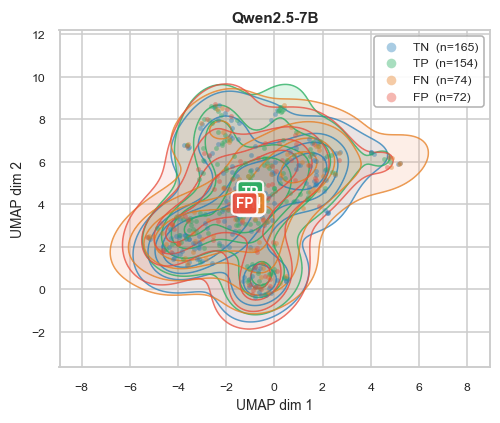

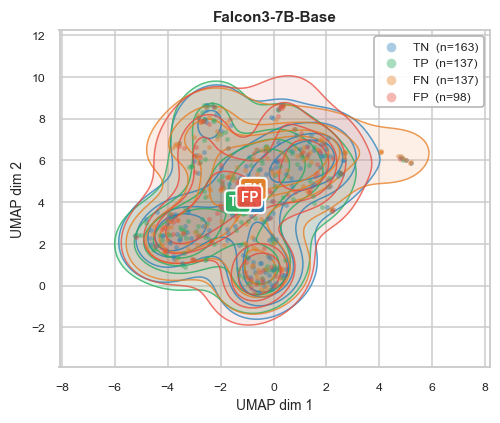

In [ ]:
# ── Plot B: all types together with filled density + labelled centroids ────────
for model in MODELS:
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sub = plot_df[plot_df["model"] == model]

    ax.scatter(sub["x_q"], sub["y_q"],
               color="#e0e0e0", alpha=0.3, s=8, linewidths=0, zorder=1)

    for et in ["TN", "TP", "FN", "FP"]:
        mask = sub["error_type"] == et
        fg   = sub[mask]

        if fg.shape[0] > 30:
            try:
                sns.kdeplot(x=fg["x_q"], y=fg["y_q"], ax=ax,
                            fill=True,  color=ET_COLORS[et], alpha=0.18,
                            levels=5, thresh=0.1, zorder=2)
                sns.kdeplot(x=fg["x_q"], y=fg["y_q"], ax=ax,
                            fill=False, color=ET_COLORS[et], alpha=0.75,
                            levels=5, thresh=0.1, linewidths=1.0, zorder=3)
            except Exception:
                pass

        ax.scatter(fg["x_q"], fg["y_q"],
                   color=ET_COLORS[et], alpha=0.4, s=10, linewidths=0,
                   label=f"{et}  (n={mask.sum()})", zorder=4)

        if not fg.empty:
            cx, cy = fg["x_q"].mean(), fg["y_q"].mean()
            ax.annotate(
                et, xy=(cx, cy),
                fontsize=9, fontweight="bold", color="white",
                ha="center", va="center", zorder=6,
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor=ET_COLORS[et],
                          edgecolor="white", linewidth=1.4, alpha=0.92),
            )

    ax.set_title(f"{model}", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"{REDUCE_METHOD.upper()} dim 1", fontsize=9)
    ax.set_ylabel(f"{REDUCE_METHOD.upper()} dim 2", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(markerscale=2, fontsize=8, loc="upper right",
              framealpha=0.92, edgecolor="#aaa")
    plt.tight_layout(pad=0.4)
    model_slug = model.replace(".", "_").replace("-", "_")
    fig.savefig(PLOTS_DIR / f"semantic_2d_all_types_{model_slug}.pdf", bbox_inches="tight")
    plt.show()


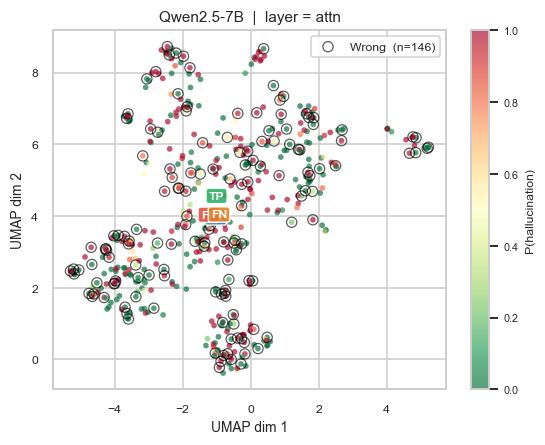

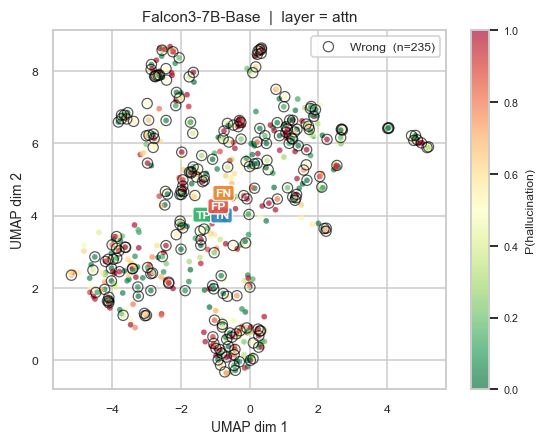

In [ ]:
# ── Plot C: confidence overlay ─────────────────────────────────────────────────
for model in MODELS:
    fig, ax = plt.subplots(figsize=(5, 4))
    sub   = plot_df[plot_df["model"] == model]
    wrong = sub[sub["error_type"].isin(["FP", "FN"])]

    sc = ax.scatter(
        sub["x_q"], sub["y_q"],
        c=sub["prob"], cmap="RdYlGn_r",
        alpha=0.65, s=14, linewidths=0, vmin=0, vmax=1, zorder=2,
    )

    ax.scatter(
        wrong["x_q"], wrong["y_q"],
        facecolors="none", edgecolors="black",
        s=45, linewidths=0.8, alpha=0.65,
        label=f"Wrong  (n={len(wrong)})", zorder=3,
    )

    for et in ET_ORDER:
        fg = sub[sub["error_type"] == et]
        if not fg.empty:
            cx, cy = fg["x_q"].mean(), fg["y_q"].mean()
            ax.annotate(
                et, xy=(cx, cy),
                fontsize=8, fontweight="bold", color="white", zorder=5,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.22",
                          facecolor=ET_COLORS[et],
                          edgecolor="white", linewidth=1.0, alpha=0.88),
            )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("P(hallucination)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    ax.set_title(f"{model}  |  layer = {LAYER_FOR_PLOT}", fontsize=10)
    ax.set_xlabel(f"{REDUCE_METHOD.upper()} dim 1", fontsize=9)
    ax.set_ylabel(f"{REDUCE_METHOD.upper()} dim 2", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
    plt.tight_layout(pad=0.4)
    model_slug = model.replace(".", "_").replace("-", "_")
    fig.savefig(PLOTS_DIR / f"semantic_2d_confidence_{model_slug}.pdf", bbox_inches="tight")
    plt.show()
